# Feature Engineering — PC Hardware Pricing
SEIS 763 | Issue #8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

df_raw = None

try:
    from google.colab import files
    uploaded = files.upload()
    name = list(uploaded.keys())[0]
    df_raw = pd.read_csv(io.BytesIO(uploaded[name]))
    print(f"Loaded {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

except ImportError:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    out = widgets.Output()

    def on_upload(change):
        global df_raw
        with out:
            clear_output()
            val = upload_btn.value
            content = val[0]['content'] if isinstance(val, (list, tuple)) else list(val.values())[0]['content']
            if hasattr(content, 'tobytes'):
                content = bytes(content)
            df_raw = pd.read_csv(io.BytesIO(content))
            print(f"Loaded {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

    upload_btn = widgets.FileUpload(accept='.csv', multiple=False, description='Upload CSV')
    upload_btn.observe(on_upload, names='value')
    display(widgets.VBox([upload_btn, out]))

Saving computer_prices_all.csv to computer_prices_all.csv
Loaded 100,000 rows, 33 columns


## 1. CPU
Keep `cpu_tier` (1–6 ordinal). Combine cores × boost into `cpu_perf_score`. Drop `cpu_base_ghz` (redundant) and `cpu_model` (26k synthetic IDs).

In [2]:
feats = pd.DataFrame(index=df_raw.index)

feats['cpu_tier']         = df_raw['cpu_tier']
feats['cpu_perf_score']   = df_raw['cpu_cores'] * df_raw['cpu_boost_ghz']
feats['cpu_thread_ratio'] = df_raw['cpu_threads'] / df_raw['cpu_cores']

feats = pd.concat([feats, pd.get_dummies(df_raw['cpu_brand'], prefix='cpu_brand')], axis=1)

feats[['cpu_tier', 'cpu_perf_score', 'cpu_thread_ratio']].describe().round(2)

,cpu_tier,cpu_perf_score,cpu_thread_ratio
count,100000.00,100000.00,100000.00
mean,3.15,38.47,1.86
std,1.37,21.80,0.33
min,1.00,11.20,1.00
25%,2.00,21.60,2.00
50%,3.00,31.20,2.00
75%,4.00,49.00,2.00
max,6.00,126.00,2.00


## 2. GPU
Keep `gpu_tier` and `vram_gb`. Add a dedicated-GPU flag. Drop `gpu_model` — 49 messy strings that add nothing over the tier.

In [3]:
feats['gpu_tier']          = df_raw['gpu_tier']
feats['vram_gb']           = df_raw['vram_gb']
feats['has_dedicated_gpu'] = (df_raw['vram_gb'] > 0).astype(int)

feats = pd.concat([feats, pd.get_dummies(df_raw['gpu_brand'], prefix='gpu_brand')], axis=1)

print(f"Dedicated: {feats['has_dedicated_gpu'].mean():.1%}  |  Integrated: {(1-feats['has_dedicated_gpu']).mean():.1%}")

Dedicated: 86.6%  |  Integrated: 13.4%


## 3. RAM
Keep `ram_gb` as numeric. Bin it into 4 tiers: ≤8 GB / 9–16 / 17–32 / >32.

In [4]:
feats['ram_gb']   = df_raw['ram_gb']
feats['ram_tier'] = pd.cut(
    df_raw['ram_gb'],
    bins=[0, 8, 16, 32, np.inf],
    labels=[1, 2, 3, 4]
).astype(int)

feats['ram_tier'].value_counts().sort_index()

,count
ram_tier,
1,18482
2,22258
3,24823
4,34437


## 4. Storage
Encode type as ordinal (HDD < SSD < NVMe). Log-transform capacity to fix the right skew.

In [5]:
storage_order = {'HDD': 1, 'eMMC': 2, 'SSD': 3, 'NVMe': 4}
feats['storage_type_score'] = df_raw['storage_type'].map(storage_order)

if feats['storage_type_score'].isna().any():
    unmapped = df_raw.loc[feats['storage_type_score'].isna(), 'storage_type'].unique()
    print(f"Unmapped storage types: {unmapped} — assigned median")
    feats['storage_type_score'].fillna(feats['storage_type_score'].median(), inplace=True)

feats['storage_gb_log']      = np.log1p(df_raw['storage_gb'])
feats['storage_drive_count'] = df_raw['storage_drive_count']
feats['has_multiple_drives'] = (df_raw['storage_drive_count'] > 1).astype(int)

feats['storage_type_score'].value_counts().sort_index()

Unmapped storage types: ['Hybrid'] — assigned median


,count
storage_type_score,
1.0,15023
3.0,24937
4.0,60040


## 5. Brand
Frequency-encode brand (market share %). Flag Apple and Razer as premium — EDA showed they price $500+ above spec-matched peers. Full target encoding is deferred to the modeling pipeline to avoid leakage.

In [6]:
brand_freq = df_raw['brand'].value_counts(normalize=True)
feats['brand_freq']       = df_raw['brand'].map(brand_freq)
feats['is_premium_brand'] = df_raw['brand'].isin({'Apple', 'Razer'}).astype(int)

print(brand_freq.round(3).to_string())

brand
Lenovo      0.160
HP          0.141
Dell        0.140
Apple       0.119
ASUS        0.102
Acer        0.099
Samsung     0.081
MSI         0.079
Gigabyte    0.049
Razer       0.030


## 6. Device & Form Factor
Binary laptop flag. Age from 2025 instead of raw release year. One-hot form factor with rare categories (<5%) collapsed to Other.

In [7]:
feats['is_laptop']  = (df_raw['device_type'] == 'Laptop').astype(int)
feats['age_years']  = 2025 - df_raw['release_year']

ff_freq = df_raw['form_factor'].value_counts(normalize=True)
rare_ff = ff_freq[ff_freq < 0.05].index
df_raw['form_factor_clean'] = df_raw['form_factor'].replace(rare_ff, 'Other')
print(f"Collapsed to Other: {list(rare_ff)}")

feats = pd.concat([feats, pd.get_dummies(df_raw['form_factor_clean'], prefix='ff')], axis=1)

feats['battery_wh']      = df_raw['battery_wh']
feats['charger_watts']   = df_raw['charger_watts']
feats['weight_kg']       = df_raw['weight_kg']
feats['psu_watts']       = df_raw['psu_watts']
feats['warranty_months'] = df_raw['warranty_months']

Collapsed to Other: ['Workstation', 'Mini-ITX']


## 7. Display
Parse resolution string to total pixels. Composite score = size × refresh rate. One-hot display type.

In [8]:
def parse_resolution(s):
    try:
        w, h = s.strip().split('x')
        return int(w) * int(h)
    except Exception:
        return np.nan

feats['resolution_px']   = df_raw['resolution'].apply(parse_resolution)
feats['display_size_in'] = df_raw['display_size_in']
feats['refresh_hz']      = df_raw['refresh_hz']
feats['display_score']   = df_raw['display_size_in'] * df_raw['refresh_hz']

feats = pd.concat([feats, pd.get_dummies(df_raw['display_type'], prefix='display')], axis=1)

feats['resolution_px'].value_counts()

,count
resolution_px,
2073600,47993
4096000,14887
3686400,14509
8294400,10950
5184000,5954
4953600,5707


## 8. Connectivity
Map WiFi to a generation number (5 / 6 / 6.5 / 7). One-hot OS.

In [9]:
feats['wifi_gen']  = df_raw['wifi'].map({'Wi-Fi 5': 5, 'Wi-Fi 6': 6, 'Wi-Fi 6E': 6.5, 'Wi-Fi 7': 7})
feats['bluetooth'] = df_raw['bluetooth']

feats = pd.concat([feats, pd.get_dummies(df_raw['os'], prefix='os')], axis=1)

## 9. Final Matrix

In [10]:
feats['price'] = df_raw['price']

nulls = feats.isnull().sum()
if nulls.any():
    print(nulls[nulls > 0])
else:
    print(f"Clean. {feats.shape[0]:,} rows × {feats.shape[1]} columns ({feats.shape[1]-1} features + price)")

feats.head(3)

Clean. 100,000 rows × 54 columns (53 features + price)


,cpu_tier,cpu_perf_score,cpu_thread_ratio,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,gpu_tier,vram_gb,has_dedicated_gpu,gpu_brand_AMD,...,display_OLED,display_QLED,display_VA,wifi_gen,bluetooth,os_ChromeOS,os_Linux,os_Windows,os_macOS,price
0,3,45.6,2.0,False,False,True,2,6,1,False,...,False,False,False,6.0,5.1,False,False,True,False,1383.99
1,4,43.2,2.0,False,False,True,4,10,1,False,...,True,False,False,6.0,5.3,False,False,True,False,2274.99
2,2,28.8,2.0,True,False,False,1,4,1,False,...,False,False,False,6.0,5.0,False,False,False,True,1879.99


In [ ]:
feats.to_csv('features_engineered.csv', index=False)
print("Saved features_engineered.csv")

## 10. Top Features by Correlation with Price

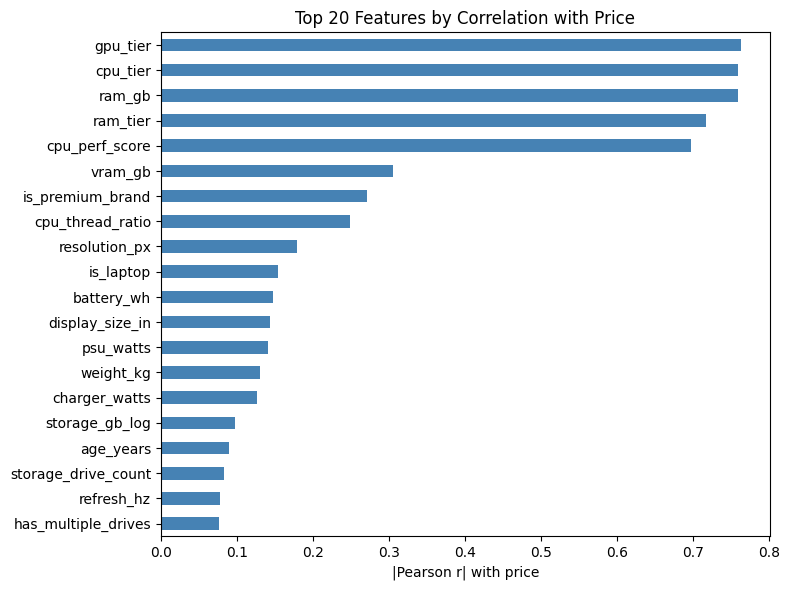

gpu_tier               0.763
cpu_tier               0.759
ram_gb                 0.759
ram_tier               0.717
cpu_perf_score         0.698
vram_gb                0.305
is_premium_brand       0.272
cpu_thread_ratio       0.248
resolution_px          0.179
is_laptop              0.154
battery_wh             0.147
display_size_in        0.143
psu_watts              0.141
weight_kg              0.131
charger_watts          0.126
storage_gb_log         0.097
age_years              0.090
storage_drive_count    0.082
refresh_hz             0.077
has_multiple_drives    0.076


In [11]:
corr = (
    feats.select_dtypes(include='number')
         .corr()['price']
         .drop('price')
         .abs()
         .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
corr.head(20).plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('|Pearson r| with price')
ax.set_title('Top 20 Features by Correlation with Price')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(corr.head(20).round(3).to_string())

## Summary of Decisions

| Dropped | Replaced with | Reason |
|---|---|---|
| `cpu_base_ghz` | — | Redundant with boost GHz |
| `cpu_cores`, `cpu_threads`, `cpu_boost_ghz` | `cpu_perf_score`, `cpu_thread_ratio` | Two composites carry the same info with less collinearity |
| `cpu_model`, `gpu_model` | tiers | Too many unique values; tier captures the same signal |
| `ram_type` | — | Field doesn't exist in the dataset |
| `storage_type` | `storage_type_score` | Ordinal encoding respects HDD < SSD < NVMe order |
| `storage_gb` | `storage_gb_log` | Log transform corrects right skew |
| `brand` | `brand_freq`, `is_premium_brand` | Avoids leakage; full target encoding happens in the model pipeline |
| `model` | model pipeline | Near-unique identifier — needs K-fold target encoding |
| `device_type` | `is_laptop` | Single binary is sufficient |
| `release_year` | `age_years` | Age relative to 2025 is more interpretable |
| `resolution` | `resolution_px` | Converts string to a usable integer |
| `form_factor` | `ff_*` dummies | One-hot encoded; rare categories grouped into Other |
| `wifi` | `wifi_gen` | Mapped to generation number for ordering |